# Exploratory Data Analysis (EDA)

## Loading the cleaned dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv(
    "https://raw.githubusercontent.com/TwinkleGhosh/Healthcare_Appointment_no_show_prediction/main/data/cleaned/healthcare_appointments_cleaned.csv"
)

In [4]:
df.shape


(110522, 15)

In [5]:
df.head()

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hypertension,Diabetes,Alcoholism,Handicap,SMS_received,No_show,WaitingDays
0,2.987250e+13,5642903,F,2016-04-29 18:38:08+00:00,2016-04-29 00:00:00+00:00,62,JARDIM DA PENHA,0,1,0,0,0,0,No,0
1,5.589978e+14,5642503,M,2016-04-29 16:08:27+00:00,2016-04-29 00:00:00+00:00,56,JARDIM DA PENHA,0,0,0,0,0,0,No,0
2,4.262962e+12,5642549,F,2016-04-29 16:19:04+00:00,2016-04-29 00:00:00+00:00,62,MATA DA PRAIA,0,0,0,0,0,0,No,0
3,8.679512e+11,5642828,F,2016-04-29 17:29:31+00:00,2016-04-29 00:00:00+00:00,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No,0
4,8.841186e+12,5642494,F,2016-04-29 16:07:23+00:00,2016-04-29 00:00:00+00:00,56,JARDIM DA PENHA,0,1,1,0,0,0,No,0


## Overall No-Show Distribution

In [ ]:
df["No_show"].value_counts()

No_show
No     88208
Yes    22314
Name: count, dtype: int64

In [ ]:
df["No_show"].value_counts(normalize=True) * 100

No_show
No     79.810354
Yes    20.189646
Name: proportion, dtype: float64

## Visualize No-Show Distribution

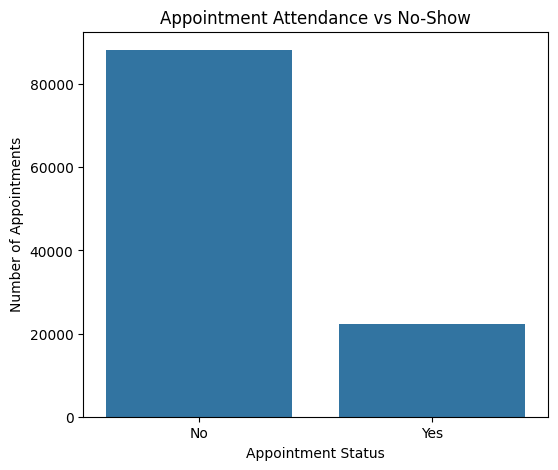

In [ ]:
plt.figure(figsize=(6, 5))

sns.countplot(data=df, x="No_show")

plt.title("Appointment Attendance vs No-Show")
plt.xlabel("Appointment Status")
plt.ylabel("Number of Appointments")

plt.show()

In [ ]:
df["No_show"].value_counts()

No_show
No     88208
Yes    22314
Name: count, dtype: int64

In [ ]:
df["No_show"].value_counts(normalize=True) * 100

No_show
No     79.810354
Yes    20.189646
Name: proportion, dtype: float64

## No-Show Rate by Gender

In [ ]:
gender_noshow = pd.crosstab(
    df["Gender"],
    df["No_show"],
    normalize="index"
) * 100

gender_noshow

No_show,No,Yes
Gender,,
F,79.68874,20.31126
M,80.03619,19.96381


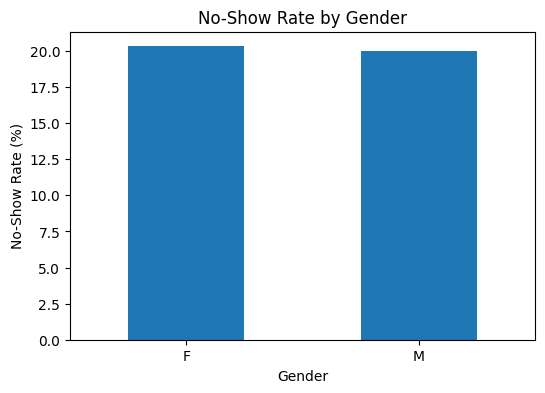

In [ ]:
gender_noshow["Yes"].plot(
    kind="bar",
    figsize=(6, 4)
)

plt.title("No-Show Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("No-Show Rate (%)")
plt.xticks(rotation=0)
plt.show()

## No-Show Rate by Age

In [ ]:
df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=[-1, 12, 18, 30, 45, 60, 75, 120],
    labels=[
        "Child (0-12)",
        "Teen (13-18)",
        "Young Adult (19-30)",
        "Adult (31-45)",
        "Middle Age (46-60)",
        "Senior (61-75)",
        "Elderly (76+)"
    ]
)

In [ ]:
age_noshow = pd.crosstab(
    df["AgeGroup"],
    df["No_show"],
    normalize="index"
) * 100

age_noshow

No_show,No,Yes
AgeGroup,,
Child (0-12),79.529356,20.470644
Teen (13-18),73.946360,26.053640
Young Adult (19-30),75.296785,24.703215
Adult (31-45),78.632595,21.367405
Middle Age (46-60),82.177833,17.822167
Senior (61-75),85.135699,14.864301
Elderly (76+),83.880542,16.119458


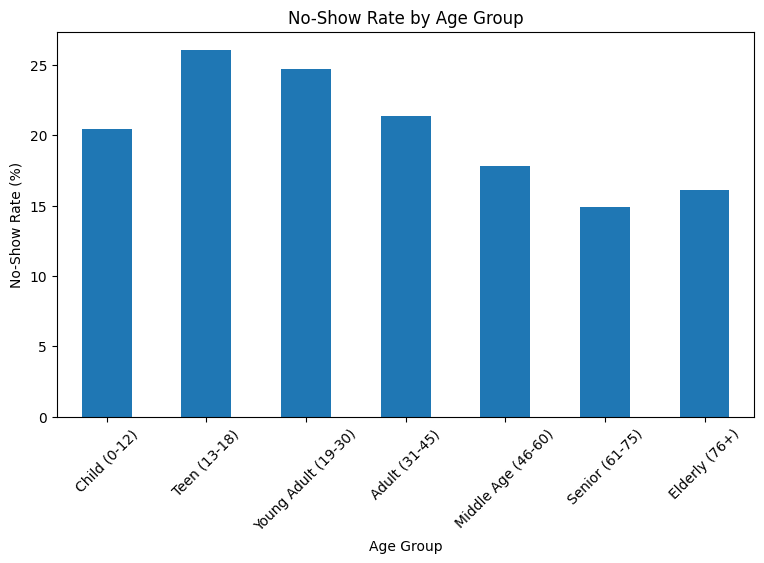

In [ ]:
age_noshow["Yes"].plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("No-Show Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("No-Show Rate (%)")
plt.xticks(rotation=45)
plt.show()

## No-Show Rate by Waiting Time

In [ ]:
df["WaitingGroup"] = pd.cut(
    df["WaitingDays"],
    bins=[-1, 0, 3, 7, 14, 30, 60, 180],
    labels=[
        "Same Day",
        "1-3 Days",
        "4-7 Days",
        "8-14 Days",
        "15-30 Days",
        "31-60 Days",
        "61+ Days"
    ]
)

In [ ]:
waiting_noshow = pd.crosstab(
    df["WaitingGroup"],
    df["No_show"],
    normalize="index"
) * 100

waiting_noshow

No_show,No,Yes
WaitingGroup,,
Same Day,95.353059,4.646941
1-3 Days,77.110733,22.889267
4-7 Days,74.797259,25.202741
8-14 Days,69.530146,30.469854
15-30 Days,67.411203,32.588797
31-60 Days,65.845708,34.154292
61+ Days,71.551313,28.448687


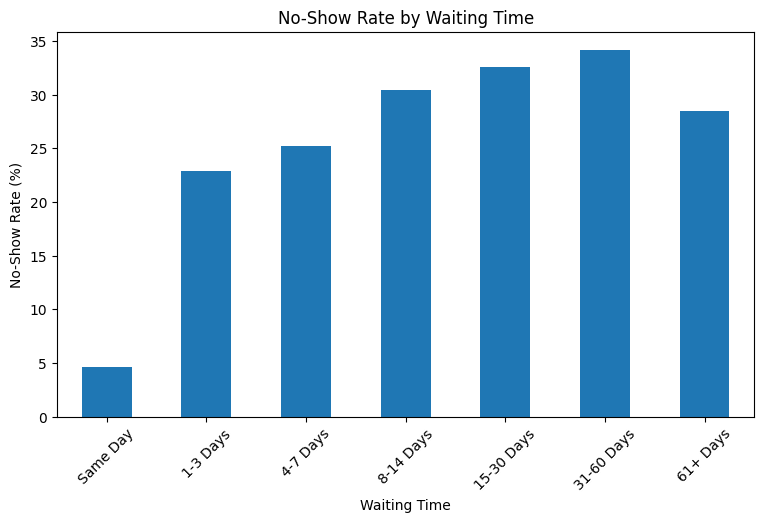

In [ ]:
waiting_noshow["Yes"].plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("No-Show Rate by Waiting Time")
plt.xlabel("Waiting Time")
plt.ylabel("No-Show Rate (%)")
plt.xticks(rotation=45)
plt.show()

## No-Show Rate by SMS Reminder

In [ ]:
sms_noshow = pd.crosstab(
    df["SMS_received"],
    df["No_show"],
    normalize="index"
) * 100

sms_noshow

No_show,No,Yes
SMS_received,,
0,83.302239,16.697761
1,72.425455,27.574545


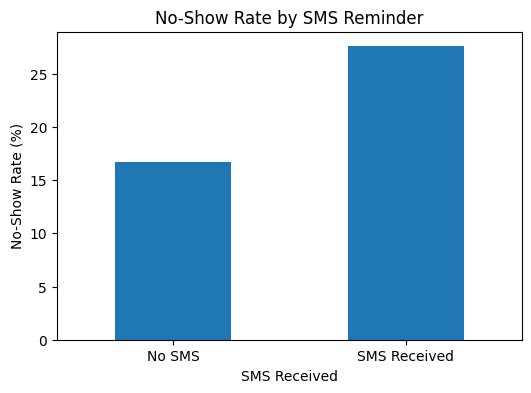

In [ ]:
sms_noshow["Yes"].plot(
    kind="bar",
    figsize=(6, 4)
)

plt.title("No-Show Rate by SMS Reminder")
plt.xlabel("SMS Received")
plt.ylabel("No-Show Rate (%)")
plt.xticks(
    [0, 1],
    ["No SMS", "SMS Received"],
    rotation=0
)
plt.show()

## No-Show Rate by Health Conditions

In [ ]:
hypertension_noshow = pd.crosstab(
    df["Hypertension"],
    df["No_show"],
    normalize="index"
) * 100

hypertension_noshow

No_show,No,Yes
Hypertension,,
0,79.100777,20.899223
1,82.698041,17.301959


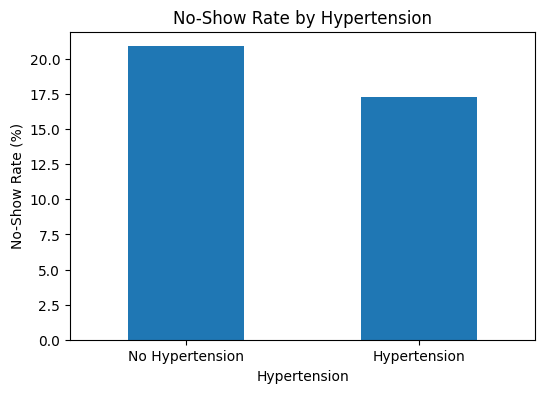

In [ ]:
hypertension_noshow["Yes"].plot(
    kind="bar",
    figsize=(6, 4)
)

plt.title("No-Show Rate by Hypertension")
plt.xlabel("Hypertension")
plt.ylabel("No-Show Rate (%)")
plt.xticks(
    [0, 1],
    ["No Hypertension", "Hypertension"],
    rotation=0
)
plt.show()


## No-Show Rate by Diabetes

In [ ]:
diabetes_noshow = pd.crosstab(
    df["Diabetes"],
    df["No_show"],
    normalize="index"
) * 100

diabetes_noshow

No_show,No,Yes
Diabetes,,
0,79.641057,20.358943
1,81.996727,18.003273


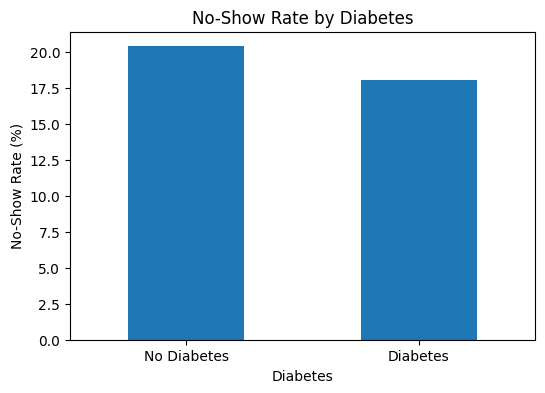

In [ ]:
diabetes_noshow["Yes"].plot(
    kind="bar",
    figsize=(6, 4)
)

plt.title("No-Show Rate by Diabetes")
plt.xlabel("Diabetes")
plt.ylabel("No-Show Rate (%)")
plt.xticks(
    [0, 1],
    ["No Diabetes", "Diabetes"],
    rotation=0
)
plt.show()

## No-Show Rate by Alcoholism

In [ ]:
alcoholism_noshow = pd.crosstab(
    df["Alcoholism"],
    df["No_show"],
    normalize="index"
) * 100

alcoholism_noshow

No_show,No,Yes
Alcoholism,,
0,79.809074,20.190926
1,79.851190,20.148810


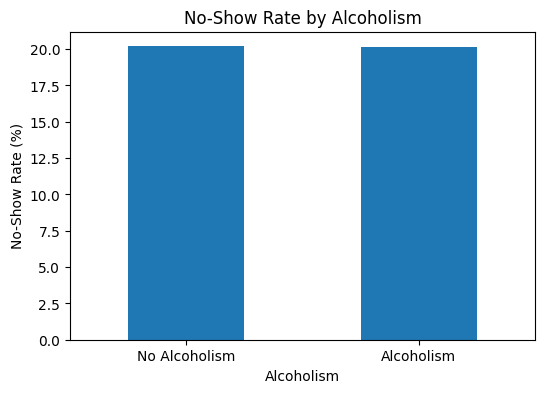

In [ ]:
alcoholism_noshow["Yes"].plot(
    kind="bar",
    figsize=(6, 4)
)

plt.title("No-Show Rate by Alcoholism")
plt.xlabel("Alcoholism")
plt.ylabel("No-Show Rate (%)")
plt.xticks(
    [0, 1],
    ["No Alcoholism", "Alcoholism"],
    rotation=0
)
plt.show()

## No-Show Rate by Handicap level

In [ ]:
handicap_noshow = pd.crosstab(
    df["Handicap"],
    df["No_show"],
    normalize="index"
) * 100

handicap_noshow

No_show,No,Yes
Handicap,,
0,79.766907,20.233093
1,82.156863,17.843137
2,79.781421,20.218579
3,76.923077,23.076923
4,66.666667,33.333333


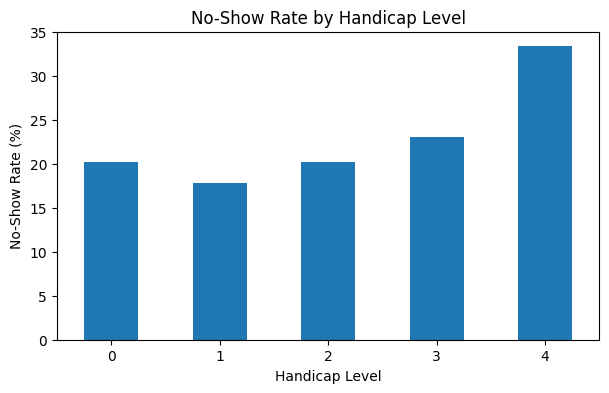

In [ ]:
handicap_noshow["Yes"].plot(
    kind="bar",
    figsize=(7, 4)
)

plt.title("No-Show Rate by Handicap Level")
plt.xlabel("Handicap Level")
plt.ylabel("No-Show Rate (%)")
plt.xticks(rotation=0)
plt.show()

## No-Show Rate by Scholarship

In [ ]:
scholarship_noshow = pd.crosstab(
    df["Scholarship"],
    df["No_show"],
    normalize="index"
) * 100

scholarship_noshow

No_show,No,Yes
Scholarship,,
0,80.196867,19.803133
1,76.263696,23.736304


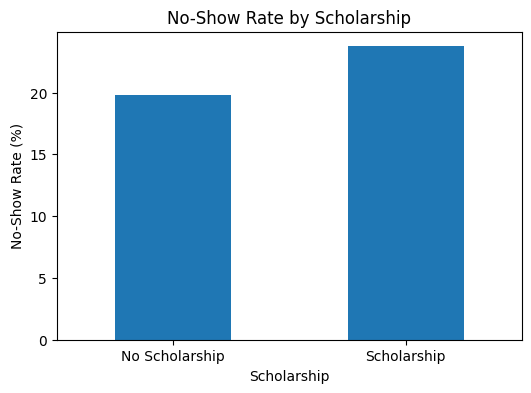

In [ ]:
scholarship_noshow["Yes"].plot(
    kind="bar",
    figsize=(6, 4)
)

plt.title("No-Show Rate by Scholarship")
plt.xlabel("Scholarship")
plt.ylabel("No-Show Rate (%)")
plt.xticks(
    [0, 1],
    ["No Scholarship", "Scholarship"],
    rotation=0
)
plt.show()

## Neighbourhood Analysis for No-Show Rate

In [ ]:
neighbourhood_counts = df["Neighbourhood"].value_counts()

neighbourhood_counts.head(10)

Neighbourhood
JARDIM CAMBURI       7717
MARIA ORTIZ          5805
RESISTÊNCIA          4430
JARDIM DA PENHA      3877
ITARARÉ              3514
CENTRO               3334
TABUAZEIRO           3131
SANTA MARTHA         3131
JESUS DE NAZARETH    2853
BONFIM               2773
Name: count, dtype: int64

In [ ]:
neighbourhood_noshow = (
    df.groupby("Neighbourhood")["No_show"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .sort_values(ascending=False)
)

neighbourhood_noshow.head(10)

Neighbourhood
ILHAS OCEÂNICAS DE TRINDADE    100.000000
SANTOS DUMONT                   28.918495
SANTA CECÍLIA                   27.455357
SANTA CLARA                     26.482213
ITARARÉ                         26.266363
JESUS DE NAZARETH               24.395373
HORTO                           24.000000
ILHA DO PRÍNCIPE                23.477493
CARATOÍRA                       23.040936
ANDORINHAS                      23.032714
Name: No_show, dtype: float64

In [ ]:
valid_neighbourhoods = neighbourhood_counts[
    neighbourhood_counts >= 100
].index

neighbourhood_noshow_100 = neighbourhood_noshow[
    neighbourhood_noshow.index.isin(valid_neighbourhoods)
]

neighbourhood_noshow_100.head(10)

Neighbourhood
SANTOS DUMONT        28.918495
SANTA CECÍLIA        27.455357
SANTA CLARA          26.482213
ITARARÉ              26.266363
JESUS DE NAZARETH    24.395373
HORTO                24.000000
ILHA DO PRÍNCIPE     23.477493
CARATOÍRA            23.040936
ANDORINHAS           23.032714
PRAIA DO SUÁ         22.826087
Name: No_show, dtype: float64

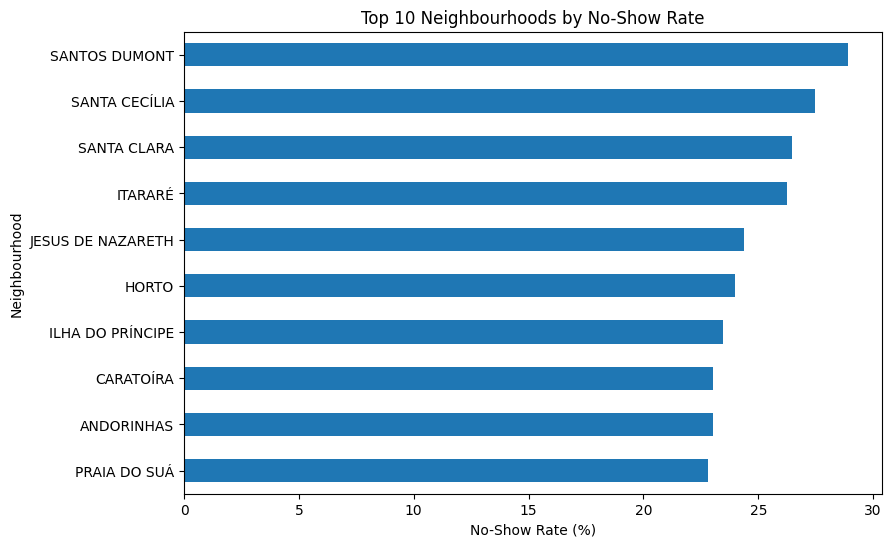

In [ ]:
neighbourhood_noshow_100.head(10).sort_values().plot(
    kind="barh",
    figsize=(9, 6)
)

plt.title("Top 10 Neighbourhoods by No-Show Rate")
plt.xlabel("No-Show Rate (%)")
plt.ylabel("Neighbourhood")

plt.show()

In [ ]:
sms_waiting = pd.crosstab(
    df["WaitingGroup"],
    df["SMS_received"],
    normalize="index"
) * 100

sms_waiting

SMS_received,0,1
WaitingGroup,,
Same Day,100.000000,0.000000
1-3 Days,93.826235,6.173765
4-7 Days,39.223301,60.776699
8-14 Days,41.754678,58.245322
15-30 Days,39.439295,60.560705
31-60 Days,38.923095,61.076905
61+ Days,35.513126,64.486874


## SMS Receipt by Waiting Time

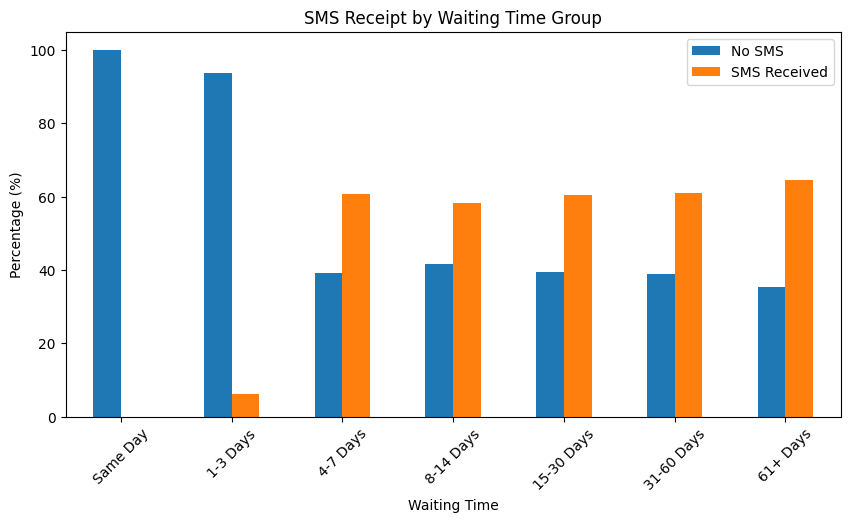

In [ ]:
sms_waiting.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("SMS Receipt by Waiting Time Group")
plt.xlabel("Waiting Time")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=45)
plt.legend(["No SMS", "SMS Received"])

plt.show()

In [ ]:
sms_waiting = pd.crosstab(
    df["WaitingGroup"],
    df["SMS_received"],
    normalize="index"
) * 100

sms_waiting.round(2)

SMS_received,0,1
WaitingGroup,,
Same Day,100.00,0.00
1-3 Days,93.83,6.17
4-7 Days,39.22,60.78
8-14 Days,41.75,58.25
15-30 Days,39.44,60.56
31-60 Days,38.92,61.08
61+ Days,35.51,64.49


In [ ]:
sms_waiting.round(2).rename(
    columns={
        0: "No SMS (%)",
        1: "SMS Received (%)"
    }
)

SMS_received,No SMS (%),SMS Received (%)
WaitingGroup,,
Same Day,100.00,0.00
1-3 Days,93.83,6.17
4-7 Days,39.22,60.78
8-14 Days,41.75,58.25
15-30 Days,39.44,60.56
31-60 Days,38.92,61.08
61+ Days,35.51,64.49


## Correlation **Heatmap**

In [6]:
df.columns

Index(['PatientId', 'AppointmentID', 'Gender', 'ScheduledDay',
       'AppointmentDay', 'Age', 'Neighbourhood', 'Scholarship', 'Hypertension',
       'Diabetes', 'Alcoholism', 'Handicap', 'SMS_received', 'No_show',
       'WaitingDays'],
      dtype='object')

In [7]:
df["No_show_numeric"] = df["No_show"].map({
    "No": 0,
    "Yes": 1
})

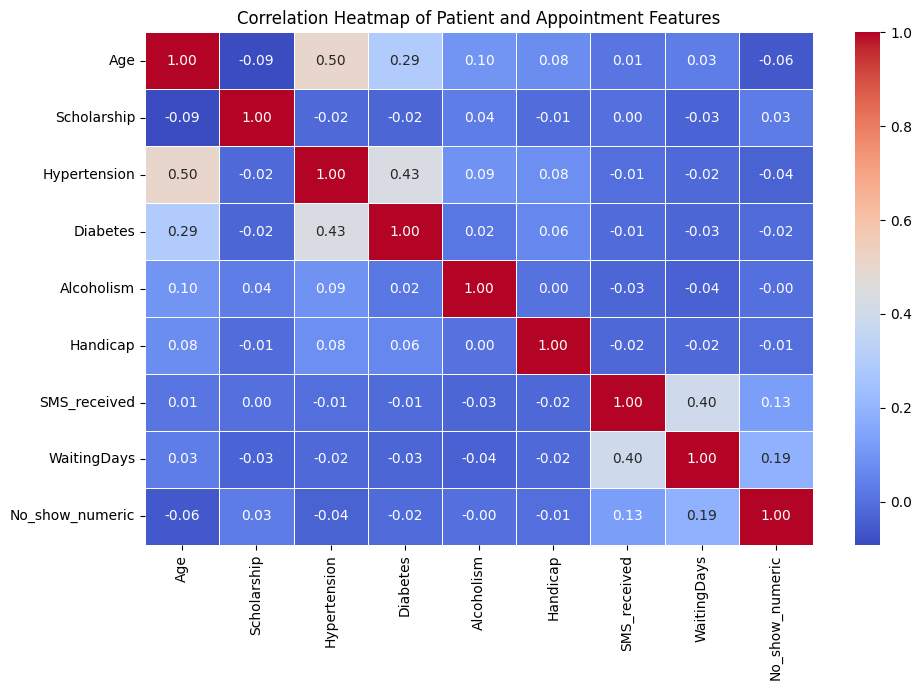

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

corr_cols = [
    "Age",
    "Scholarship",
    "Hypertension",
    "Diabetes",
    "Alcoholism",
    "Handicap",
    "SMS_received",
    "WaitingDays",
    "No_show_numeric"
]

corr = df[corr_cols].corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Patient and Appointment Features")
plt.tight_layout()
plt.show()